In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings
# 忽略所有警告 (建議在開發完成、確認邏輯正確後再使用)
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

# 解決中文顯示問題 (針對 Windows 系統)
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # 設定字體為微軟正黑體
plt.rcParams['axes.unicode_minus'] = False              # 解決負號 '-' 顯示為亂碼的問題

In [35]:
import pandas as pd
import os

# 設定路徑
path = 'data/'

# 1. 讀取並直接設定
#  index
data1 = pd.read_csv(os.path.join(path, 'market_indices.csv'), encoding='utf-8-sig')
data1['日期'] = pd.to_datetime(data1['日期'])
data1.set_index('日期', inplace=True)

data2 = pd.read_csv(os.path.join(path, 'vix_index.csv'), encoding='utf-8-sig')
data2['日期'] = pd.to_datetime(data2['日期'])
data2.set_index('日期', inplace=True)

data3 = pd.read_csv(os.path.join(path, 'futures_chip.csv'), encoding='utf-8-sig')
data3['日期'] = pd.to_datetime(data3['日期'])
data3.set_index('日期', inplace=True)

data4 = pd.read_csv(os.path.join(path, 'margin_and_legal.csv'), encoding='utf-8-sig')
data4['日期'] = pd.to_datetime(data4['日期'])
data4.set_index('日期', inplace=True)

print("🎯 所有資料表的 Index 已轉換為『日期』。")
# 檢查其中一個表的結果


🎯 所有資料表的 Index 已轉換為『日期』。


In [ ]:
vix = data2[["VIX_收盤價"]]
twa00 = data1["加權報酬指數:收盤價"]

tw_returns = data1["加權報酬指數:收盤價"].pct_change().dropna()
vix["大盤"] = tw_returns
vix["vix_change"] = vix["VIX_收盤價"].pct_change().dropna() 
vix.dropna(inplace=True)
vix.loc[(vix["大盤"]>0.015)&(vix["vix_change"]>0), "signal"] = 1 
vix.fillna(0, inplace=True)
vix_strange_up = vix[vix["signal"] ==   1]
vix_strange_up


,VIX_收盤價,大盤,vix_change,signal
日期,,,,
2010-04-26,20.00,0.019145,0.017812,1.0
2010-09-13,16.59,0.025596,0.034289,1.0
2011-04-06,16.34,0.016869,0.001225,1.0
2012-02-08,20.52,0.021080,0.017857,1.0
2012-07-31,18.52,0.015998,0.020386,1.0
2015-04-23,13.08,0.019192,0.138381,1.0
2015-08-31,27.53,0.019685,0.033796,1.0
2015-11-04,16.16,0.016510,0.116793,1.0
2017-06-26,12.17,0.019297,0.170192,1.0


,VIX_收盤價,大盤,vix_change,signal
日期,,,,
2010-01-15,17.53,0.008072,-0.010722,NaN
2010-01-18,19.71,-0.002282,0.124358,NaN
2010-01-19,18.87,-0.010653,-0.042618,NaN
2010-01-20,19.17,-0.003403,0.015898,NaN
2010-01-21,15.47,-0.011320,-0.193010,NaN
...,...,...,...,...
2026-03-18,31.81,0.015142,-0.088016,NaN
2026-03-19,35.70,-0.019049,0.122289,NaN
2026-03-20,34.83,-0.004289,-0.024370,NaN


In [94]:
vix

,VIX_收盤價,大盤,vix_change,signal
日期,,,,
2010-01-15,17.53,0.008072,-0.010722,0.0
2010-01-18,19.71,-0.002282,0.124358,0.0
2010-01-19,18.87,-0.010653,-0.042618,0.0
2010-01-20,19.17,-0.003403,0.015898,0.0
2010-01-21,15.47,-0.011320,-0.193010,0.0
...,...,...,...,...
2026-03-18,31.81,0.015142,-0.088016,0.0
2026-03-19,35.70,-0.019049,0.122289,0.0
2026-03-20,34.83,-0.004289,-0.024370,0.0


,VIX_收盤價,大盤,vix_change,signal
日期,,,,
2010-04-26,20.00,0.019145,0.017812,1.0
2010-09-13,16.59,0.025596,0.034289,1.0
2011-04-06,16.34,0.016869,0.001225,1.0
2012-02-08,20.52,0.021080,0.017857,1.0
2012-07-31,18.52,0.015998,0.020386,1.0
2015-04-23,13.08,0.019192,0.138381,1.0
2015-08-31,27.53,0.019685,0.033796,1.0
2015-11-04,16.16,0.016510,0.116793,1.0
2017-06-26,12.17,0.019297,0.170192,1.0


In [5]:
#外資累計買賣超
fi = data4["外資買賣超"].cumsum()

In [6]:
#分產業外資累計買賣超
fi_3ind  = pd.DataFrame({
    "傳產外資買賣超": data4["不含金電外資買賣超"].cumsum(),
    "金融外資買賣超": data4["金融外資買賣超"].cumsum(),     
    "電子外資買賣超": data4["電子外資買賣超"].cumsum()
})


In [1]:
fi_3ind

NameError: name 'fi_3ind' is not defined

<Axes: xlabel='日期'>

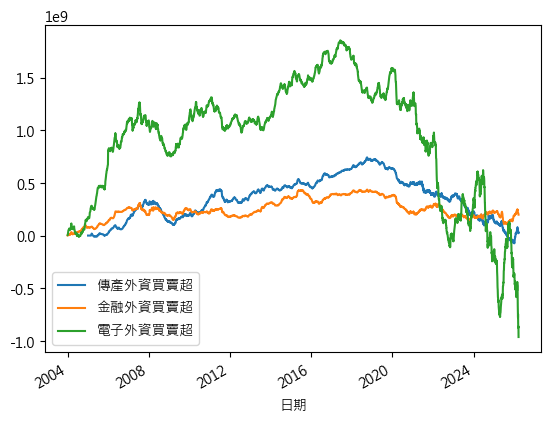

In [7]:
fi_3ind.plot()

In [8]:

#投信累計買賣超
i1= data4["投信買賣超"].cumsum()


#自營商累計買賣超
i2= data4["自營商買賣超"].cumsum()


In [9]:
#上市櫃乖離差

In [10]:
def calculate_deviation(data, window=60):
    return (data - data.rolling(window=window).mean()) / data.rolling(window=window).mean() * 100
otc_deviation = calculate_deviation(data1["OTC指數:收盤價"])
market_deviation = calculate_deviation(data1["加權指數:收盤價"])

mo_deviation = market_deviation-otc_deviation


<Axes: xlabel='日期'>

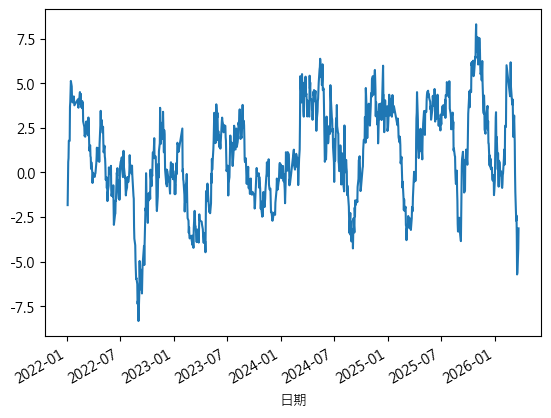

In [11]:
mo_deviation.loc['2022':].plot()



In [12]:
#電金乖離差、電傳乖離差
tech_deviation = calculate_deviation(data1["電子類:收盤價"])
fin_devation = calculate_deviation(data1["金融保險:收盤價"])
tra_deviation = calculate_deviation(data1["不含金融電子:收盤價"])

#電金乖離差
tech_fin_deviation = tech_deviation - fin_devation
#電傳乖離差
tech_tra_deviation = tech_deviation - tra_deviation


In [13]:
# 散戶淨部位

law = data3["MTX01自營商:多方未平倉"] + data3["MTX02投信:多方未平倉"] +data3["MTX03外資:多方未平倉"] - data3["MTX01自營商:空方未平倉"] - data3["MTX02投信:空方未平倉"] - data3["MTX03外資:空方未平倉"]    
mob = (-law).rolling(window=5).mean()

In [14]:
#外資淨部位
foreign_net =  data3["TX03外資:期貨多方未平倉"] - data3["TX03外資:期貨空方未平倉"]

In [15]:
#電子成交比重-市值比重

In [16]:
weight_diff = data1["電子類:成交值比重(%)"] - data1["電子類:市值比重(%)"]

In [17]:
#oi


In [18]:
data3["TXOC台指選近月:全部未沖銷"]
data3["TXOC1台指選近月:全部未沖銷"]
data3["TXOP台指選近月:全部未沖銷"] 
data3["TXOP1台指選近月:全部未沖銷"]

日期
2004-01-02         NaN
2004-01-05         NaN
2004-01-06         NaN
2004-01-07         NaN
2004-01-08         NaN
                ...   
2026-03-16    153013.0
2026-03-17    177964.0
2026-03-18     57013.0
2026-03-19     90186.0
2026-03-20     63942.0
Name: TXOP1台指選近月:全部未沖銷, Length: 5464, dtype: float64

In [19]:
#pcr近月
pcr = data3["TXOP台指選近月:全部未沖銷"] / data3["TXOC台指選近月:全部未沖銷"]

In [20]:
#所有月
put_oi = data3["TXOP1台指選近月:全部未沖銷"]

call_oi = data3["TXOC1台指選近月:全部未沖銷"]

In [21]:
#融資融券餘額
data4["券餘"]
data4["融資餘額"]

日期
2004-01-02    272547417
2004-01-05    274279482
2004-01-06    274678946
2004-01-07    275634321
2004-01-08    276615684
                ...    
2026-03-16    392284076
2026-03-17    393467032
2026-03-18    399772079
2026-03-19    402095986
2026-03-20    398591129
Name: 融資餘額, Length: 5464, dtype: int64

In [22]:
close = pd.read_csv("close.csv", encoding='utf-8-sig')

In [23]:
import pandas as pd

# 假設你的 DataFrame 名稱為 close
# 1. 處理欄位名稱：如果是日期欄位就去掉「收盤價」，如果是「股票代號」等則保留原樣
new_columns = []
for col in close.columns:
    if '收盤價' in col:
        # 去掉「收盤價」字眼
        date_str = col.replace('收盤價', '')
        # 轉換為 datetime 物件 (格式為 YYYYMMDD)
        new_columns.append(pd.to_datetime(date_str, format='%Y%m%d'))
    else:
        # 保留「股票代號」、「股票名稱」等原欄位
        new_columns.append(col)

# 2. 將處理完的列表重新指派給 columns
close.columns = new_columns

In [24]:
close.set_index("股票代號", inplace=True)

In [25]:
close = close.T

In [26]:
close.index = pd.to_datetime(close.index, format='%Y%m%d')

In [27]:
#有資料的股票數
total = (~close.isna()).sum(axis=1)

In [28]:
upon_ma = (((close-close.rolling(window=60).mean())/close.rolling(window=60).mean() )>0).sum(axis=1)

In [29]:
upon_ratio  = upon_ma/total

In [30]:
returns = close.pct_change()

In [31]:
# import numpy as np
# import pandas as pd

# def avg_corr_fast(df, window=60):
#     res = []
#     idx = []

#     for i in range(window - 1, len(df)):
#         sub = df.iloc[i - window + 1:i + 1]

#         # 標準化
#         z = (sub - sub.mean()) / sub.std(ddof=1)

#         # 轉 numpy（快很多）
#         Z = z.to_numpy()

#         # 去掉 nan column
#         mask = ~np.isnan(Z).any(axis=0)
#         Z = Z[:, mask]

#         m = Z.shape[1]
#         if m < 2:
#             res.append(np.nan)
#             idx.append(df.index[i])
#             continue

#         # covariance matrix (用矩陣乘法)
#         C = (Z.T @ Z) / (window - 1)

#         avg_corr = (C.sum() - m) / (m * (m - 1))

#         res.append(avg_corr)
#         idx.append(df.index[i])

#     return pd.Series(res, index=idx)

In [32]:
corr = avg_corr_fast(returns, window=60)

NameError: name 'avg_corr_fast' is not defined

In [ ]:
corr.to_csv("corr.csv", encoding='utf-8-sig')

In [ ]:
corr

2010-04-06         NaN
2010-04-07    0.313350
2010-04-08    0.312896
2010-04-09    0.313204
2010-04-12    0.308288
                ...   
2026-03-24    0.192737
2026-03-25    0.196390
2026-03-26    0.195731
2026-03-27    0.194065
2026-03-30    0.193771
Length: 3919, dtype: float64

In [ ]:
data1["加權報酬指數:收盤價"]

,加權指數:收盤價,加權報酬指數:收盤價,電子類:收盤價,金融保險:收盤價,不含金融電子:收盤價,OTC指數:收盤價,不含金融電子報酬指數:收盤價,電子類報酬指數:收盤價,金融保險類報酬指數:收盤價,電子類:成交值比重(%),電子類:市值比重(%)
日期,,,,,,,,,,,
2010-01-14,8289.98,10633.60,343.45,904.30,9753.27,148.85,12599.61,398.52,998.90,69.745,55.614
2010-01-15,8356.89,10719.43,347.34,908.55,9788.93,149.79,12645.68,403.04,1003.59,69.403,55.795
2010-01-18,8337.82,10694.97,346.66,903.40,9774.76,150.28,12627.39,402.24,997.91,68.407,55.813
2010-01-19,8249.00,10581.04,342.04,901.74,9683.38,148.75,12509.34,396.88,996.07,68.889,55.621
2010-01-20,8220.93,10545.03,341.55,887.24,9664.72,148.60,12485.22,396.32,980.05,67.726,55.733
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-18,34348.58,78311.56,2139.08,2451.80,14170.62,329.40,33816.88,4379.28,4710.54,83.310,79.347
2026-03-19,33689.68,76819.80,2095.85,2413.35,13958.73,329.79,33312.13,4291.49,4636.67,80.343,79.253
2026-03-20,33543.88,76490.31,2085.73,2423.60,13865.21,328.40,33096.90,4270.82,4656.36,81.583,79.208
